/tmp/ipython-input-490852969.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_micro, labels=order)


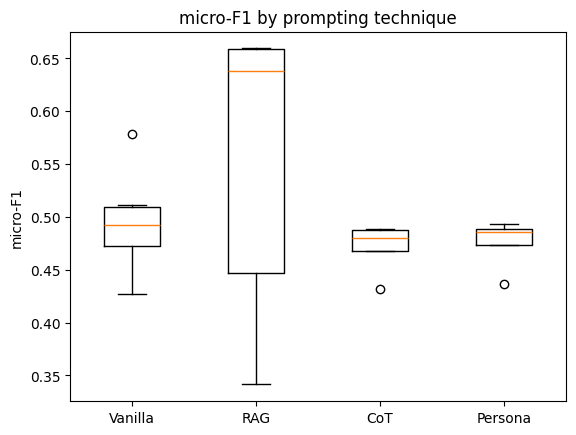

/tmp/ipython-input-490852969.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_macro, labels=order)


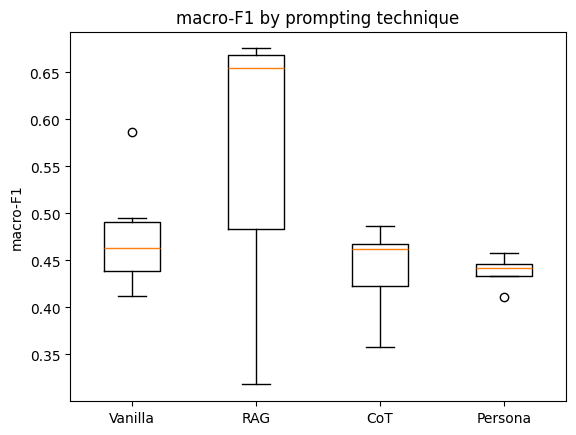

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) 요약 CSV 불러오기
van = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_Vanilla.csv")  # Vanilla
rag = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_RAG.csv")  # RAG
cot = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_CoT.csv")  # CoT
per = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_Persona.csv") # Persona

# 2) technique 컬럼 추가
van["technique"] = "Vanilla"
rag["technique"] = "RAG"
cot["technique"] = "CoT"
per["technique"] = "Persona"

# 3) 하나로 합치기
df = pd.concat([van, rag, cot, per], ignore_index=True)

# 4) micro-F1 박스플롯
order = ["Vanilla", "RAG", "CoT", "Persona"]
data_micro = [df.loc[df["technique"]==t, "micro_F1"].dropna().values for t in order]

plt.figure()
plt.boxplot(data_micro, labels=order)
plt.ylabel("micro-F1")
plt.title("micro-F1 by prompting technique")
plt.show()

# 5) macro-F1 박스플롯
data_macro = [df.loc[df["technique"]==t, "macro_F1"].dropna().values for t in order]

plt.figure()
plt.boxplot(data_macro, labels=order)
plt.ylabel("macro-F1")
plt.title("macro-F1 by prompting technique")
plt.show()


/tmp/ipython-input-3592168506.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_micro, labels=order)


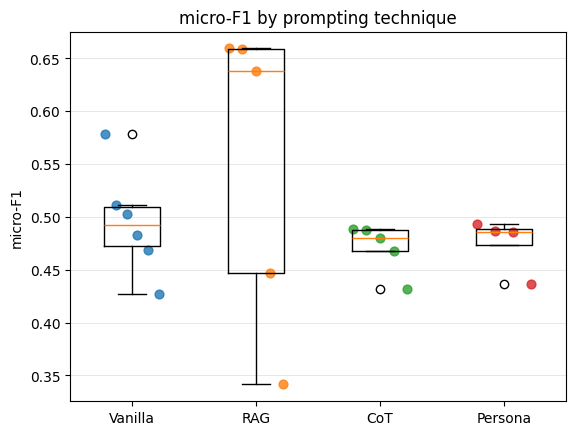

/tmp/ipython-input-3592168506.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_macro, labels=order)


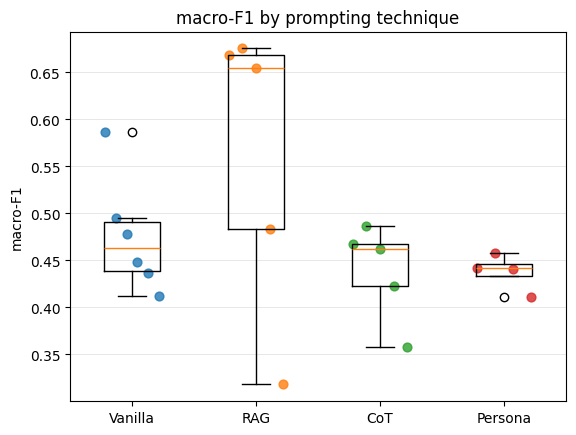

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) 요약 CSV 불러오기
van = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_Vanilla.csv")  # Vanilla
rag = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_RAG.csv")      # RAG
cot = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_CoT.csv")      # CoT
per = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_Persona.csv")  # Persona

# 2) technique 컬럼 추가
van["technique"] = "Vanilla"
rag["technique"] = "RAG"
cot["technique"] = "CoT"
per["technique"] = "Persona"

# 3) 하나로 합치기
df = pd.concat([van, rag, cot, per], ignore_index=True)

# (안전) 숫자로 변환
df["micro_F1"] = pd.to_numeric(df["micro_F1"], errors="coerce")
df["macro_F1"] = pd.to_numeric(df["macro_F1"], errors="coerce")

# 4) micro-F1 박스플롯 + 점 + 그리드
order = ["Vanilla", "RAG", "CoT", "Persona"]
data_micro = [df.loc[df["technique"]==t, "micro_F1"].dropna().values for t in order]

plt.figure()
plt.boxplot(data_micro, labels=order)
plt.ylabel("micro-F1")
plt.title("micro-F1 by prompting technique")

# --- 그리드(뒤에 선) ---
ax = plt.gca()
ax.set_axisbelow(True)
ax.grid(True, axis="y", linewidth=0.6, alpha=0.35)

# --- 점 추가(겹치지 않게 등간격으로 좌우 분산) ---
spread = 0.22  # 점이 좌우로 퍼지는 폭(원하면 0.30까지 키우세요)
for i, t in enumerate(order, start=1):
    vals = df.loc[df["technique"]==t, "micro_F1"].dropna().values
    n = len(vals)
    if n == 0:
        continue
    offsets = np.linspace(-spread, spread, n)  # n개 점을 일정 간격으로
    xs = i + offsets
    plt.scatter(xs, vals, s=40, alpha=0.8)

plt.show()

# 5) macro-F1 박스플롯 + 점 + 그리드
data_macro = [df.loc[df["technique"]==t, "macro_F1"].dropna().values for t in order]

plt.figure()
plt.boxplot(data_macro, labels=order)
plt.ylabel("macro-F1")
plt.title("macro-F1 by prompting technique")

ax = plt.gca()
ax.set_axisbelow(True)
ax.grid(True, axis="y", linewidth=0.6, alpha=0.35)

spread = 0.22
for i, t in enumerate(order, start=1):
    vals = df.loc[df["technique"]==t, "macro_F1"].dropna().values
    n = len(vals)
    if n == 0:
        continue
    offsets = np.linspace(-spread, spread, n)
    xs = i + offsets
    plt.scatter(xs, vals, s=40, alpha=0.8)

plt.show()


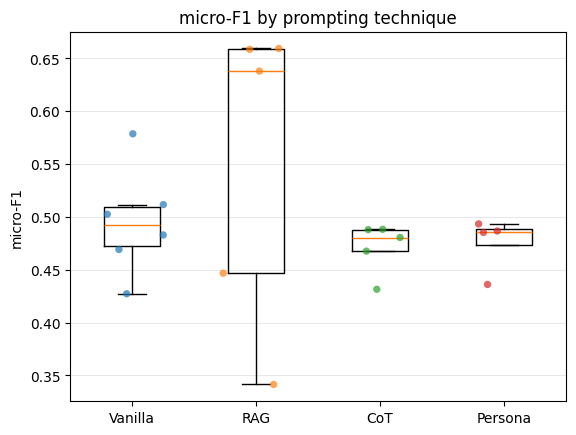

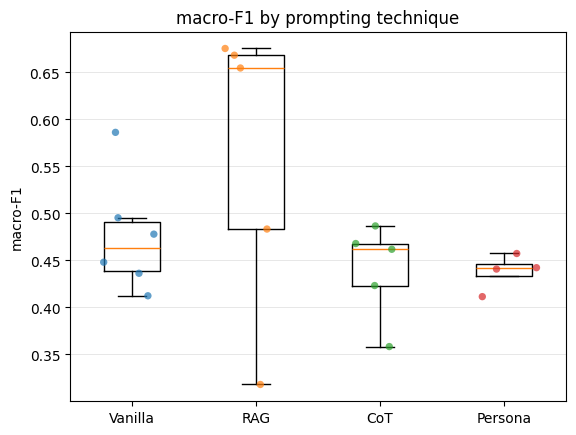

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) 요약 CSV 불러오기
van = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_Vanilla.csv")
rag = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_RAG.csv")
cot = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_CoT.csv")
per = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalue_summary_Persona.csv")

# 2) technique 컬럼 추가
van["technique"] = "Vanilla"
rag["technique"] = "RAG"
cot["technique"] = "CoT"
per["technique"] = "Persona"

# 3) 하나로 합치기
df = pd.concat([van, rag, cot, per], ignore_index=True)

# 숫자형 보장(혹시 문자열이면 scatter가 이상해질 수 있음)
df["micro_F1"] = pd.to_numeric(df["micro_F1"], errors="coerce")
df["macro_F1"] = pd.to_numeric(df["macro_F1"], errors="coerce")

order = ["Vanilla", "RAG", "CoT", "Persona"]

def box_with_scatter(metric, title, seed):
    data = [df.loc[df["technique"]==t, metric].dropna().values for t in order]

    plt.figure()
    ax = plt.gca()

    # 박스플롯: fliers(검은 빈 원) 제거 + 박스 폭 조절
    ax.boxplot(
        data,
        tick_labels=order,
        widths=0.45,
        showfliers=False
    )

    # grid
    ax.set_axisbelow(True)
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.35)

    # 점: 예시처럼 “흩뿌려 보이게”
    rng = np.random.default_rng(seed)
    for i, t in enumerate(order, start=1):
        vals = df.loc[df["technique"]==t, metric].dropna().values.astype(float)
        n = len(vals)
        if n == 0:
            continue

        # 지터 폭을 키우면(0.22~0.30) 더 ‘흩어진 느낌’이 납니다
        xs = np.full(n, i) + rng.uniform(-0.28, 0.28, size=n)

        ax.scatter(xs, vals, s=28, alpha=0.7, edgecolors="none", zorder=3)

    ax.set_ylabel(metric.replace("_", "-"))
    ax.set_title(title)
    plt.show()

box_with_scatter("micro_F1", "micro-F1 by prompting technique", seed=1)
box_with_scatter("macro_F1", "macro-F1 by prompting technique", seed=2)


In [ ]:
df.groupby("technique").size()

,0
technique,
CoT,5
Persona,4
RAG,5
Vanilla,6


base     opp    
CoT      Persona    6
RAG      CoT        6
         Persona    6
Vanilla  CoT        6
         Persona    6
         RAG        6
dtype: int64


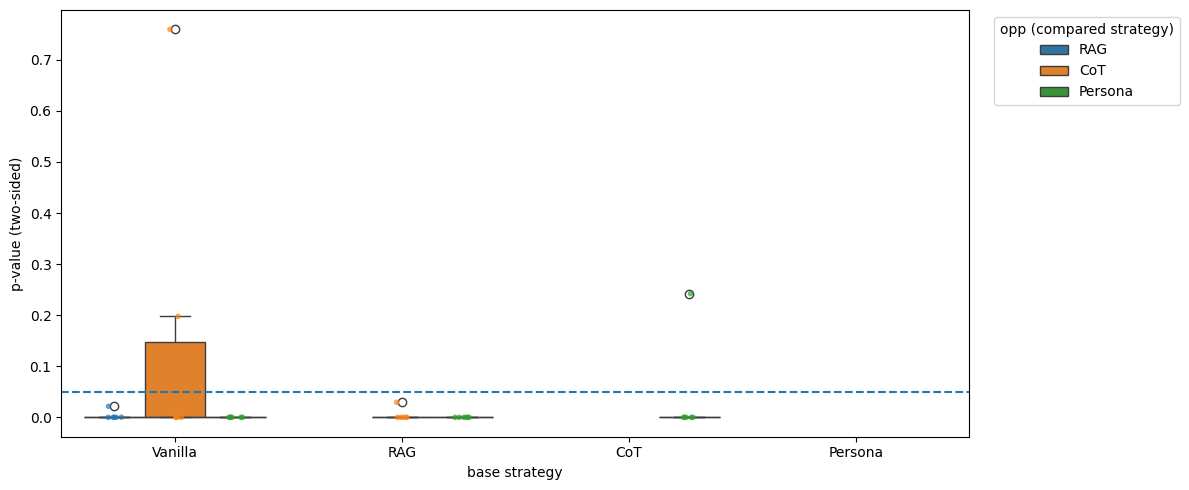

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 파일 불러오기
df = pd.read_csv("/content/drive/MyDrive/MP_KORHateSpeechDetection/pvalues_strategy_pairs_macroF1_modelpaired_B3000.csv")

# 2) 전략 순서(중복 방지용 방향 고정)
order = ["Vanilla", "RAG", "CoT", "Persona"]
rank = {s: i for i, s in enumerate(order)}

# 3) (strategy_A, strategy_B)를 (base, opp)로 정렬해서 배치
#    - 항상 base가 앞(낮은 rank), opp가 뒤(높은 rank)
def to_base_opp(row):
    a, b = row["strategy_A"], row["strategy_B"]
    if rank[a] <= rank[b]:
        return pd.Series([a, b])
    else:
        return pd.Series([b, a])

df[["base", "opp"]] = df.apply(to_base_opp, axis=1)

# (선택) 제대로 묶였는지 확인: 각 (base, opp) 조합이 6개씩 나와야 정상입니다.
print(df.groupby(["base", "opp"]).size())

# 4) 박스플롯 (x축 4개, hue로 상대 전략 표시)
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df,
    x="base",
    y="p_value_two_sided",
    hue="opp",
    order=order,
    hue_order=["RAG", "CoT", "Persona"],  # opp는 항상 뒤쪽 전략만 나오므로 이렇게 두면 깔끔합니다.
    showfliers=True
)

# (추천) 점도 같이 찍어서, 모델 6개가 실제로 어떻게 분포하는지 보이게 하기
sns.stripplot(
    data=df,
    x="base",
    y="p_value_two_sided",
    hue="opp",
    order=order,
    hue_order=["RAG", "CoT", "Persona"],
    dodge=True,
    size=4,
    alpha=0.7
)

# stripplot 때문에 범례가 2번 생기므로, 한 번만 남기기
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="opp (compared strategy)", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.axhline(0.05, linestyle="--")
plt.ylabel("p-value (two-sided)")
plt.xlabel("base strategy")
plt.tight_layout()
plt.show()
